In [1]:
import numpy as np
from random import *
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import csv

# Criterions

Depending on the type of problem (classification or regression) and the quanttiative criteria used to split nodes, we may need different expressions. In order to make the code clear and avoid writing it twice we regroup everything related to node splitting and evaluation of the leaves in one class. 

In [2]:
class Criterion:
    """
    Class to store specificities due to the type of tree (regression/classificaion) and to the criterion used
    entrop, variance, gini index...
    """
    def initialize(self, ySorted):
        pass
    def moveSample(self, y):
        pass
    def score(self):
        pass
    def output(self, ySorted):
        pass
  
class VarianceCriterion(Criterion):
    def initialize(self, ySorted):
        """
        Initialize the saved values to compute the variance of the left and right nodes after a split
        """
        self.N = len(ySorted)
        self.leftN = 0 
        self.leftSum = 0 
        self.leftSum2 = 0

        self.rightN = self.N
        self.rightSum = np.sum(np.array(ySorted))
        self.rightSum2 = np.sum(np.array(ySorted)**2)
    
    def moveSample(self, y):
        """
        Update the saved values knowing that the y eleement has been moved from the right node to the left node
        """
        self.leftN += 1
        self.rightN -= 1

        self.leftSum += y
        self.rightSum -= y

        self.leftSum2 += y**2
        self.rightSum2 -= y**2
        
    def score(self):
        """
        compute the variance of the left and right nodes after a split and return the weighted average of these variances
        """
        if self.N == 0:
            return 0
        varianceLeft = self.leftSum2/self.leftN  - (self.leftSum/self.leftN)**2 
        varianceRight = self.rightSum2/self.rightN  - (self.rightSum/self.rightN)**2 
        return -(varianceLeft*self.leftN + varianceRight*self.rightN)/self.N
    
    def output(self, ySorted):
        """
        Return the mean of the y values in the node as output for regression trees
        """
        return np.mean(ySorted)
    
class EntropyCriterion(Criterion):
    def initialize(self, ySorted):
        self.N = len(ySorted)

        classes = set(ySorted)
        self.mapping = {val: i for i, val in enumerate(classes)}

        self.leftCount = 0
        self.leftNumbers = np.zeros(len(classes))

        self.rightCount = self.N
        self.rightNumbers = np.array([np.sum(ySorted == c) for c in classes])
    
    def moveSample(self, y):
        self.leftCount += 1
        self.rightCount -= 1

        self.leftNumbers[self.mapping[y]] += 1
        self.rightNumbers[self.mapping[y]] -= 1
        
    def score(self):
        entropyLeft = entropy(self.leftNumbers/self.leftCount)
        entropyRight = entropy(self.rightNumbers/self.rightCount)
        return (entropyLeft*self.leftCount + entropyRight*self.rightCount)/self.N
    
    def output(self, ySorted):
        counts = np.bincount(ySorted.astype(int))
        return np.argmax(counts)

def entropy(probabilities):
  return np.sum(probabilities * np.log2(probabilities + 1e-10))


# Node structure

Nodes will contain:
-  the score of the split they perform (if they are not a leaf)
-  their depth and 
-  the number of samples at that point of the tree
-  the index chosen to cut and its corresponding cutting threshold
-  the output if this is a leaf

In [3]:
class Node :
    def __init__(self):
        self.score = None

        self.nSamples = None
        self.depth = None

        self.featureIndex = None
        self.featureThreshold = None
        
        self.left = None
        self.right = None

        self.output = None

    def __str__(self):
        return self._to_string()
    
    def _to_string(self, espace=0):
        indent = " " * espace

        if self.left is None and self.right is None:
            return f"{indent}[{self.output:.2f}]\n"

        text = f"{indent}[X{self.featureIndex} {self.featureThreshold:.2f}]\n"

        if self.left is not None:
            text += self.left._to_string(espace + 2)
        if self.right is not None:
            text += self.right._to_string(espace + 2)

        return text

# Tree strucrure

In [4]:
class DecisionTree :
    def __init__(self, criterion, maxDepth=10, minSamplesSplit=2, minSamplesLeaf=1):
        self.max_depth = maxDepth
        self.minSamplesSplit = minSamplesSplit
        self.minSamplesLeaf = minSamplesLeaf

        self.root = None

        self.criterion = criterion
        
        self.tree = None

    def best_split(self, X, y, numberOfArgs):
        N = len(y)

        bestIndex , bestThreshold, bestScore = None, None, -1000
        attributs = sample([k for k in range(len(X[0]))], numberOfArgs)
        for index in attributs :
            #Sort by the current attribute
            seuils, classes = zip(*sorted(zip(X[:, index], y)))
            self.criterion.initialize(classes)
            
            for i in range(self.minSamplesLeaf, N-self.minSamplesLeaf):
                self.criterion.moveSample(classes[i-1])
                if seuils[i] == seuils[i-1]:
                    continue
                
                score = self.criterion.score()
                if score > bestScore :
                    bestScore = score
                    bestIndex = index
                    bestThreshold = (seuils[i] + seuils[i-1]) / 2 
        return bestIndex, bestThreshold, bestScore

    def planting(self, X, y, numberOfArgs,  depth=0):
        m = y.size
        node = Node()

        node.depth = depth
        node.nSamples = m
        
        def makeLeaf():
            node.output = self.criterion.output(y)
            return node
        if m <= self.minSamplesSplit or depth > self.max_depth:
            return makeLeaf()

        index, seuil, score = self.best_split(X, y, numberOfArgs)
        if index == None :
            return makeLeaf()
        indexLeft = X[:, index] < seuil
        XLeft, yLeft = X[indexLeft] , y[indexLeft]
        XRight, yRight = X[np.logical_not(indexLeft)], y[np.logical_not(indexLeft)]
        
        if len(yLeft) == 0 or len(yRight) == 0:
            return makeLeaf()
        
        node.featureIndex = index
        node.featureThreshold = seuil

        node.left = self.planting(XLeft, yLeft, numberOfArgs,  depth + 1)
        node.right = self.planting(XRight, yRight, numberOfArgs,  depth + 1)
        node.score = score   
        return node

    def fit(self, X, y, numberOfArgs):
        self.tree = self.planting(X, y, numberOfArgs)
        
    def prediction(self, input):
        
        node = self.tree
        while node.left!= None :
            if input[node.featureIndex] < node.featureThreshold  :
                node = node.left
            else :
                node = node.right
        return node.output

    def predictions(self, X):
        return [self.prediction(entrees) for entrees in X]
    
    def __str__(self):
        return self.tree.__str__()
    


# Random forest

In [5]:
class RandomForest :
    def __init__(self, nTrees, criterion, maxDepth=10, minSampleSplit=2, minSamplesLeaf=1, numberOfArgs = 6):
        self.nTrees = nTrees
        self.trees = [DecisionTree(criterion, maxDepth, minSampleSplit, minSamplesLeaf) for _ in range(nTrees)]
        self.numberOfArgs = numberOfArgs
    
    def bagging(self, data):
        samples = []
        n = len(data)
        for _ in range(self.nTrees): 
            tempBag = []
            for _ in range(n):
                tempBag += [data[randrange(0, n)]]
            samples += [tempBag]
        return samples
    
    def make(self, data):
        samples = self.bagging(data)
        for idx, sample in enumerate(samples):
            self.trees[idx].fit(np.array(sample)[:, :-1], np.array(sample)[:, -1], self.numberOfArgs)
        
    def predict(self, inputs) :
        predit = []
        for input in inputs :
            predit += [1/self.nTrees* np.sum([tree.prediction(input) for tree in self.trees])]
        return predit
        

In [6]:
def predictor(data, numerOfTrees, numberOfArgs, criterion = VarianceCriterion(), maxDepth = 8, minSampleSplit = 2, minSamplesLeaf = 1,):

    train, test = train_test_split(data, test_size = 0.25)

    forest = RandomForest(numerOfTrees, criterion, 
                          maxDepth=maxDepth, minSampleSplit=minSampleSplit,
                          minSamplesLeaf=minSamplesLeaf, 
                          numberOfArgs=numberOfArgs)
    forest.make(train)
    
    erreurTrain = erreurTest = 0
    L1 = forest.predict(np.array(test)[:, :-1])
    L2 = forest.predict(np.array(train)[:, :-1])

    for k in range(len(L1)) :
        erreurTest += (L1[k] - test[k][-1])**2
    for k in range(len(L2)) :
        erreurTrain += (L2[k] - train[k][-1])**2
    
    erreurTest = np.sqrt(erreurTest/len(L1))
    erreurTrain = np.sqrt(erreurTrain/len(L2))
    return forest, erreurTest, erreurTrain, L1, test

In [7]:
def readData(file, delta = 2, indexes = [4, 7, 8, 9, 10, 11, 12]):
    donnees = csv.reader(file, delimiter=',')
    k, X, Y=0, [], []
    for k, ligne in enumerate(donnees):
        if k == 0:
            continue  # skip header
        def f(i):
            if i == 4 or i == 7:
                return float(ligne[i].replace(",", "."))**(-3)
            if i == 12:
                return np.abs(float(ligne[i].replace(",", ".")))
            if i == 8 or i == 10:
                return float(ligne[i].replace(",", "."))**2
            return float(ligne[i].replace(",", "."))
        y = f(1)

        x = [f(i) for i in indexes]
        
        X.append(x)
        Y.append(y)

    X, Y = X[:2499-delta], Y[delta:]
    for k in range(len(X)):
        X[k] += [Y[k] - 20]
    return np.array(X)

# Influence of preparing the data

Raw data
* $\theta$, $\phi$, $R_{ST}$  Soleil
* $\theta$, $\phi$, $R_{LT}$ Lune

Transformed data
* $\cos(\theta)$, $\sin(\theta)$, $\cos(\phi)$, $\sin(\phi)$, $1/R_{ST}^2$, Soleil
* $\cos(\theta)$, $\sin(\theta)$, $\cos(\phi)$, $\sin(\phi)$, $1/R_{ST}^2$, Lune
* $\cos(\theta_S - \theta_L)$,  $\sin(\theta_S - \theta_L)$

Data from current day, previous ...

# Using only raw data

In [ ]:
file = open("data.csv","r")
names = np.array(["Coeff Brest", "Coeff Have", 'ThetaS','PhiS','RS','ThetaL','PhiL','RL','cos(ThetaS)',
         'sin(ThetaS)','cos(ThetaL)','sin(ThetaL)','cos(deltaTheta)','VRS','VRL' ,'sin(deltaTheta)'])
indexes = [2, 3, 4, 5, 6, 7]
data = readData(file, delta = 0, indexes = indexes)
numberOfTrees = 20
numberOfArgs = 5
maxDepth = 5
criterion = VarianceCriterion()
minSamplesSplit = 2
minSamplesLeaf = 1

forest, errorTest, errorTrain, L1, test = predictor(
            data,
            numberOfTrees,
            numberOfArgs,
            criterion,
            maxDepth,
            minSamplesSplit,
            minSamplesLeaf
        )

print(names[indexes])
print(forest.trees[0])
print("Errors with raw data from the corresponding day")
print("Test error: {:.1f}".format(errorTest), "Train error: {:.1f}".format(errorTrain))

['ThetaS' 'PhiS' 'RS' 'ThetaL' 'PhiL' 'RL']
[X5 165211.65]
  [X5 147833.00]
    [X5 136109.32]
      [X4 4.43]
        [X2 1.03]
          [X0 205.87]
            [51.50]
            [57.46]
          [34.50]
        [X4 4.83]
          [X3 129.86]
            [51.00]
            [41.50]
          [X3 109.86]
            [49.00]
            [33.20]
      [X0 5.63]
        [X5 139440.60]
          [X1 0.00]
            [54.50]
            [27.00]
          [X0 2.53]
            [79.33]
            [63.67]
        [X4 3.18]
          [X4 -5.15]
            [25.96]
            [42.38]
          [X5 140992.44]
            [30.21]
            [42.74]
    [X4 -5.18]
      [X2 1.02]
        [X0 276.62]
          [X2 1.00]
            [21.82]
            [27.33]
          [13.00]
        [56.00]
      [X1 0.00]
        [X3 55.25]
          [X2 1.02]
            [65.14]
            [47.12]
          [X3 163.97]
            [44.38]
            [54.61]
        [X3 142.40]
          [X3 56.10]
   

# Using Transformed data
As angles are periodical, values close to 0 and equivalent to value close to 360 but the tree sees them as completly different. To encode directly the periodicity in the data we can replace $\theta$ and $\phi$ by their cosinus and sinus. USing insights from physics we also know that hjaving the sun and the moon aligned leas to greater tides as they effects add up. This means that $\theta_S - \theta_L = 0 [\pi]$ corresponds generally to higher tides, therefore we add the cosinus of the difference which should equal to 0 when they are perpendicular and 1 when they are aligned.

In [ ]:
file = open("data.csv","r")
names = np.array(["Coeff Brest", "Coeff Have", 'ThetaS','PhiS','RS','ThetaL','PhiL','RL','cos(ThetaS)',
         'sin(ThetaS)','cos(ThetaL)','sin(ThetaL)','cos(deltaTheta)','VRS','VRL' ,'sin(deltaTheta)'])
indexes = [4, 7, 8, 9, 10, 11, 12]
data = readData(file, delta = 0, indexes = indexes)
numberOfTrees = 20
numberOfArgs = 5
maxDepth = 10
criterion = VarianceCriterion()
minSamplesSplit = 2
minSamplesLeaf = 1

forest, errorTest, errorTrain, L1, test = predictor(
            data,
            numberOfTrees,
            numberOfArgs,
            criterion,
            maxDepth,
            minSamplesSplit,
            minSamplesLeaf
        )

print(names[indexes])
print(forest.trees[0])
print("Errors with tranformed data from the corresponding day")
print("Test error: {:.1f}".format(errorTest), "Train error: {:.1f}".format(errorTrain))

['RS' 'RL' 'cos(ThetaS)' 'sin(ThetaS)' 'cos(ThetaL)' 'sin(ThetaL)'
 'cos(deltaTheta)']
[X1 164568.13]
  [X6 0.75]
    [X1 148564.93]
      [X6 0.52]
        [X1 139567.84]
          [X0 0.98]
            [X6 0.14]
              [X1 137096.51]
                [33.00]
                [X0 0.97]
                  [X0 0.97]
                    [28.00]
                    [25.50]
                  [X6 0.06]
                    [X2 0.33]
                      [14.00]
                      [17.00]
                    [X3 0.96]
                      [24.00]
                      [19.00]
              [X4 0.23]
                [X5 0.93]
                  [18.00]
                  [12.00]
                [X3 0.79]
                  [X1 138263.28]
                    [X5 0.16]
                      [44.00]
                      [44.00]
                    [X2 0.75]
                      [55.00]
                      [51.00]
                  [X5 0.13]
                    [X1 138247.82]
           

# Influence of the day and inertia

Oceans take times to move so the coefficients might depend on previous configuration than current one. To investigate this point, I try to use data from previous days and look at the precision as a function of the time difference between the inputs and the outputs.

0
1
2
3
4
5


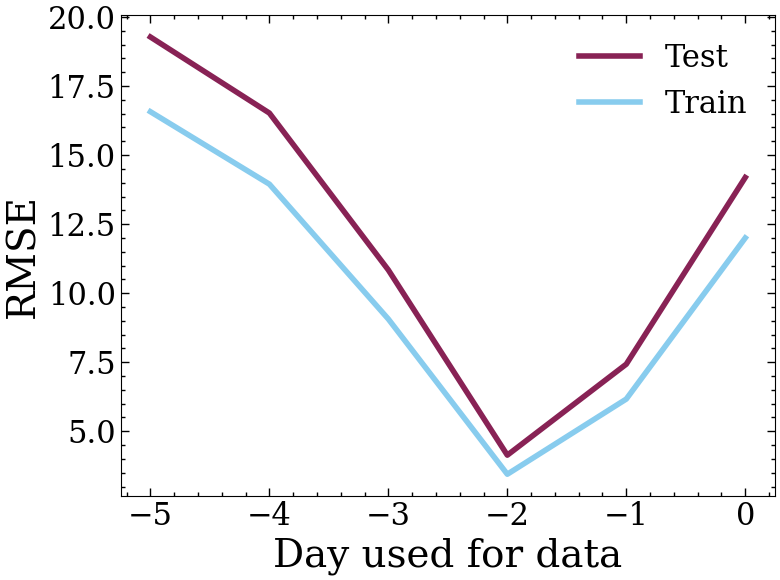

In [ ]:

names = np.array(["Coeff Brest", "Coeff Have", 'ThetaS','PhiS','RS','ThetaL','PhiL','RL','cos(ThetaS)',
         'sin(ThetaS)','cos(ThetaL)','sin(ThetaL)','cos(deltaTheta)','VRS','VRL' ,'sin(deltaTheta)'])
indexes = [4, 7, 8, 9, 10, 11, 12]
numberOfTrees = 10
numberOfArgs = 5
maxDepth = 5
criterion = VarianceCriterion()
minSamplesSplit = 2
minSamplesLeaf = 1
errorTests = []
errorTrains = []

for delta in range(6): 
    print(delta)
    testTemp = 0
    trainTemp = 0
    for i in range(5):
        file = open("data.csv","r")
        data = readData(file, delta = delta, indexes = indexes)
        forest, errorTest, errorTrain, L1, test = predictor(
                    data,
                    numberOfTrees,
                    numberOfArgs,
                    criterion,
                    maxDepth,
                    minSamplesSplit,
                    minSamplesLeaf
                )
        testTemp += errorTest
        trainTemp += errorTrain
    errorTests += [testTemp/5]
    errorTrains += [trainTemp/5]

plt.plot(-np.arange(0, 6), errorTests, label = "Test")
plt.plot(-np.arange(0, 6), errorTrains, label = "Train")
plt.xlabel("Day used for data")
plt.ylabel("RMSE")
plt.savefig("influece_of_day.svg")
plt.legend()
plt.show()

# Choice of hyper-parameters

For random forest, one can control many different hyper-parameters: number of trees, number of arguments chosen at random, depth of the trees, classification VS regression...

To choose the best ones, we should look at the precision of the predictor but also the difference between train et test errors to ensure that the forest is ablte to generalize.

In [ ]:
import itertools
import json

file = open("data.csv", "r")
data = readData(file, delta=2)

minSamplesSplit = 2
minSamplesLeaf = 1
criterion = VarianceCriterion()

numberOfTreesToTry = [1, 5, 10, 20, 50, 100]
numberOfArgsToTry = [1, 2, 3, 4, 5, 6, 7]
maxDepthToTry = [2, 4, 6, 8, 10]

results = []

for n_trees, n_args, depth in itertools.product(
    numberOfTreesToTry,
    numberOfArgsToTry,
    maxDepthToTry
):
    avgErrorTest = 0
    avgErrorTrain = 0

    for i in range(5):
        forest, errorTest, errorTrain, L1, test = predictor(
            data,
            n_trees,
            n_args,
            criterion,
            depth,
            minSamplesSplit,
            minSamplesLeaf
        )

        avgErrorTest += errorTest
        avgErrorTrain += errorTrain

    avgErrorTest /= 5
    avgErrorTrain /= 5

    print(
        f"n_trees: {n_trees}, n_args: {n_args}, max_depth: {depth}, "
        f"test_error: {avgErrorTest:.4f}, train_error: {avgErrorTrain:.4f}"
    )

    results.append({
        "n_trees": n_trees,
        "n_args": n_args,
        "max_depth": depth,
        "test_error": avgErrorTest,
        "train_error": avgErrorTrain
    })

# trier les meilleurs modèles
results = sorted(results, key=lambda x: x["test_error"])

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

n_trees: 1, n_args: 1, max_depth: 2, test_error: 15.6585, train_error: 15.5223
n_trees: 1, n_args: 1, max_depth: 4, test_error: 13.4394, train_error: 12.2692
n_trees: 1, n_args: 1, max_depth: 6, test_error: 11.5443, train_error: 10.2098
n_trees: 1, n_args: 1, max_depth: 8, test_error: 11.6823, train_error: 9.3556
n_trees: 1, n_args: 1, max_depth: 10, test_error: 14.1859, train_error: 10.1256
n_trees: 1, n_args: 2, max_depth: 2, test_error: 13.0051, train_error: 12.5984
n_trees: 1, n_args: 2, max_depth: 4, test_error: 10.6602, train_error: 10.1254
n_trees: 1, n_args: 2, max_depth: 6, test_error: 8.3871, train_error: 7.0134
n_trees: 1, n_args: 2, max_depth: 8, test_error: 8.0442, train_error: 5.7977
n_trees: 1, n_args: 2, max_depth: 10, test_error: 8.6783, train_error: 5.5739
n_trees: 1, n_args: 3, max_depth: 2, test_error: 12.7422, train_error: 12.2326
n_trees: 1, n_args: 3, max_depth: 4, test_error: 7.6848, train_error: 6.9551
n_trees: 1, n_args: 3, max_depth: 6, test_error: 7.2794, tr

In [ ]:
import json
with open("results.json", "r", encoding="utf-8") as f:
    data = json.load(f)


trees = sorted(set(d["n_trees"] for d in data))
args = sorted(set(d["n_args"] for d in data))
depths = sorted(set(d["max_depth"] for d in data))

# Dictionnaires pour mapping index
t_idx = {v: i for i, v in enumerate(trees)}
a_idx = {v: i for i, v in enumerate(args)}
d_idx = {v: i for i, v in enumerate(depths)}

# Tableau 4D : (trees, args, depth, 2 erreurs)
grid = np.zeros((len(trees), len(args), len(depths), 2))

# Remplissage
for item in data:
    i = t_idx[item["n_trees"]]
    j = a_idx[item["n_args"]]
    k = d_idx[item["max_depth"]]

    grid[i, j, k, 0] = item["test_error"]
    grid[i, j, k, 1] = item["train_error"]

# Influence of tree depth

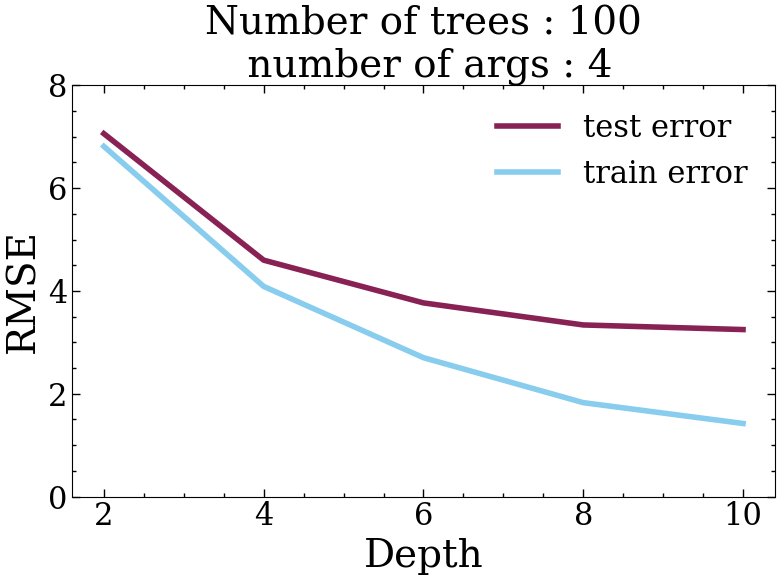

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

numberOfTreesToTry = [1, 5, 10, 20, 50, 100]
numberOfArgsToTry = [1, 2, 3, 4, 5,6, 7]
maxDepthToTry = [2, 4, 6, 8, 10]
idx_tree = 5
idx_args = 3
plt.title("Number of trees : {}\n number of args : {}".format(numberOfTreesToTry[idx_tree], numberOfArgsToTry[idx_args]))
plt.plot(maxDepthToTry, grid[idx_tree,idx_args,:,0], label = "test error", color=colors[0])
plt.plot(maxDepthToTry, grid[idx_tree,idx_args,:,1], label = "train error", color=colors[1])
plt.xlabel("Depth")
plt.ylabel("RMSE")
plt.ylim([0, 8])
plt.legend()
plt.show()

# Influence of forest size

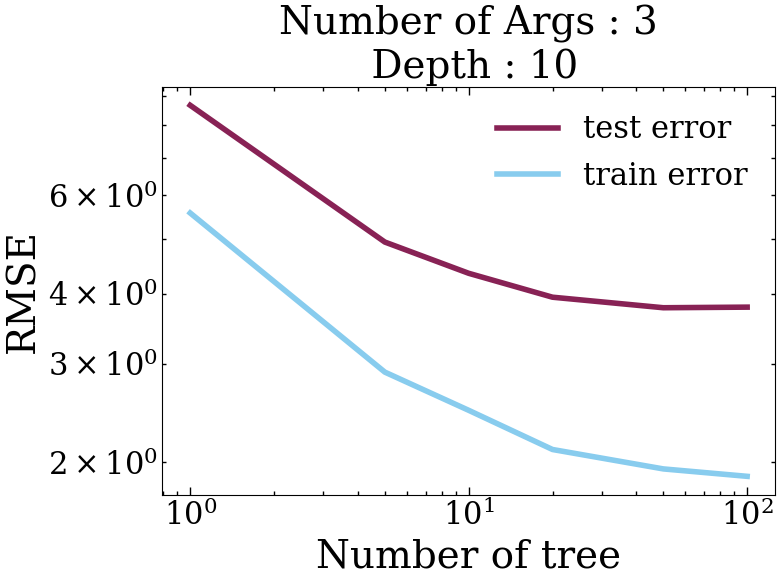

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

numberOfTreesToTry = [1, 5, 10, 20, 50, 100]
numberOfArgsToTry = [1, 3, 5, 7]
maxDepthToTry = [2, 4, 6, 8, 10]
idx_args = 1
idx_depth = 4
plt.title("Number of Args : {}\n Depth : {}".format( numberOfArgsToTry[idx_args], maxDepthToTry[idx_depth]))
plt.plot(numberOfTreesToTry, grid[:,idx_args,idx_depth,0], label = "test error", color=colors[0])
plt.plot(numberOfTreesToTry, grid[:,idx_args,idx_depth,1], label = "train error", color=colors[1])
plt.xlabel("Number of tree")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("RMSE")
#plt.ylim([0, 8])
plt.legend()
plt.show()

# Influence of number of chosen arguments

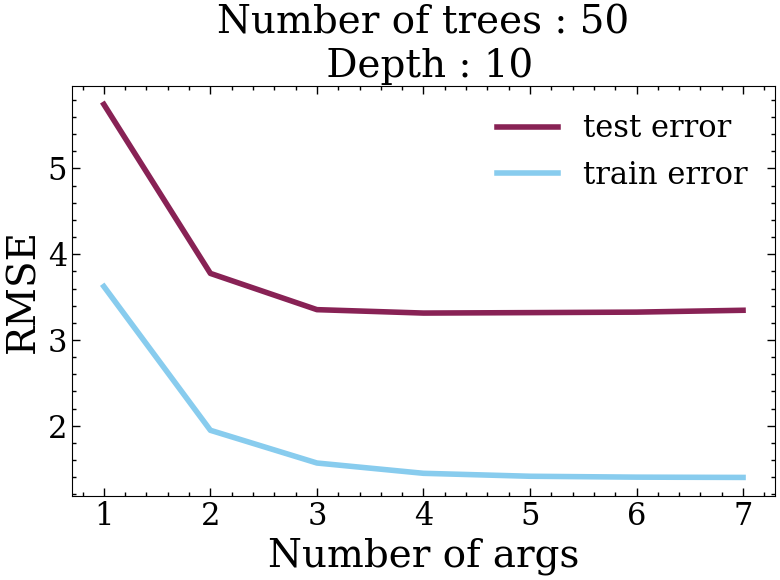

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

numberOfTreesToTry = [1, 5, 10, 20, 50, 100]
numberOfArgsToTry = [1, 2, 3, 4, 5,6, 7]
maxDepthToTry = [2, 4, 6, 8, 10]
idx_tree = 4
idx_depth = 4
plt.title("Number of trees : {}\n Depth : {}".format( numberOfTreesToTry[idx_tree], maxDepthToTry[idx_depth]))
plt.plot(numberOfArgsToTry, grid[idx_tree,:,idx_depth,0], label = "test error", color=colors[0])
plt.plot(numberOfArgsToTry, grid[idx_tree,:,idx_depth,1], label = "train error", color=colors[1])
plt.xlabel("Number of args")
#plt.xscale("log")
plt.ylabel("RMSE")
#plt.ylim([0, 8])
plt.legend()
plt.show()

# Prediction versus real values

3.397039939552587


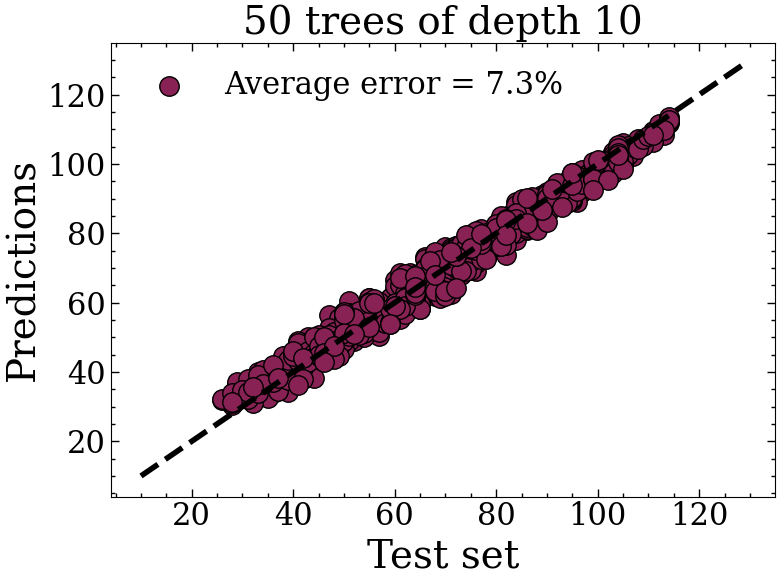

In [ ]:

indexes = [4, 7, 8, 9, 10, 11, 12]
numberOfTrees = 50
numberOfArgs = 3
maxDepth = 10
criterion = VarianceCriterion()
minSamplesSplit = 2
minSamplesLeaf = 1


file = open("data.csv","r")
data = readData(file, delta = 2, indexes = indexes)
forest, errorTest, errorTrain, L1, test = predictor(
    data,
    numberOfTrees,
    numberOfArgs,
    criterion,
    maxDepth,
    minSamplesSplit,
    minSamplesLeaf
)
print(errorTest)
error = np.mean(np.abs(np.array(test)[:,-1]- np.array(L1))/np.array(L1))
plt.scatter(np.array(test)[:,-1]+20, np.array(L1)[:]+20, edgecolor="black", label = "Average error = {:.1f}%".format(100*error))
plt.xlabel("Test set")
plt.ylabel("Predictions")
plt.plot(np.arange(10, 130), np.arange(10, 130), ls = "dashed", color="black")
plt.title("50 trees of depth 10")
plt.legend()
#plt.savefig("test_predictions.svg")
plt.show()

0.983327627 0.002689989 4.8935541567417005 3.897858215699936
0.983322454 0.002705156 4.911321845891782 4.106564083769497
0.983321531 0.002713817 4.929115536957058 4.313667774492312
0.983324715 0.002716622 4.946910050072413 4.5200228987349345
0.983331894 0.00271432 4.964704992538763 4.72634994412055
0.983342989 0.002707612 4.982499954203736 4.93326455459885
0.983357954 0.00269704 5.000294516188309 5.141319119896774
0.983376783 0.002682931 5.0180882491414875 5.351050759855633
0.983399511 0.002665396 5.035880723712276 5.563027594854917
0.983426212 0.002644403 5.053671514040335 5.777884406379563
0.983457005 0.002619895 5.0714602134639515 5.99633843224969
0.983492051 0.002591966 5.0892464310293715 6.219176110844931
0.983531555 0.002561038 5.107029812434757 0.16401713319659567
0.983575762 0.002528032 5.124810038284854 0.39796153737281365
0.983624951 0.002494484 5.142586848525606 0.6383401327430938
0.983679431 0.002462557 5.160360052916123 0.8852863410021047
0.983739521 0.002434902 5.17812953

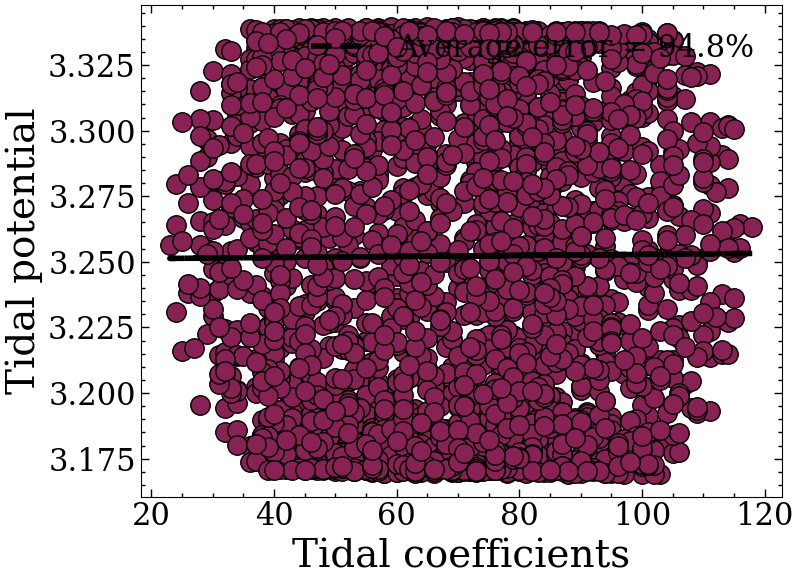

In [ ]:
def caldelta(tS,tL, TS, TL) :
    ML = 7.4e22
    MS= 2e30
    cst = 1.5*(6.4e6)**4/6e24
    cstS =cst*MS/(TS*1.5e11)**3
    cstL = cst*ML/(TL*1.5e11)**3
    K = np.linspace(0, 1, 720)
    M = np.max(1*(3*(np.cos(tS + (K * np.pi))**2) -1 ) + 1*(3*(np.cos(tL + (K * np.pi))**2 ) -1 ))

    m = np.min(1*(3*(np.cos(tS + (K * np.pi))**2) -1 ) + 1*(3*(np.cos(tL + (K * np.pi))**2 ) -1 ))
    return M - m

def CalculExplicite() :  
    file=open("data.csv","r")
    donnees=csv.reader(file)  
    k=0
    X=[]
    Y=[]
    for row in donnees :
        if k!=0 :
            print(float(row[4].replace(",", ".")), float(row[7].replace(",", ".")), float(row[2].replace(",", "."))*np.pi/180, float(row[5].replace(",", "."))*np.pi/180)
            x = caldelta(float(row[2].replace(",", "."))*np.pi/180, float(row[5].replace(",", "."))*np.pi/180, float(row[4].replace(",", ".")), float(row[7].replace(",", ".")))
            y = float(row[1].replace(",", "."))
            X += [x]
            Y += [y]
        k+=1
    return np.array(X), np.array(Y)
X, Y = CalculExplicite()
print(X, Y)
pol = np.polyfit(Y[2:],  X[:-2], 1)
print(pol)
reg_lin = Y[2:]*pol[0]+pol[1]
error = np.mean(np.abs(Y[2:]- reg_lin)/(Y[2:]))
plt.scatter(Y[2:], X[:-2], edgecolor="black")
plt.plot(Y[2:], reg_lin, ls = "dashed", color="black", label = "Average error = {:.1f}%".format(100*error))
plt.ylabel("Tidal potential")
plt.xlabel("Tidal coefficients")
plt.legend()
plt.show()

In [21]:
print(0.57/0.25, 0.1887/0.0820)

2.28 2.301219512195122
